# Firstly, we would want to generate some graph using the SBM-family models and make some basic observations

### SBM Simulation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from graspologic.simulations import sbm
from graspologic.plot import heatmap

sns.set_context('talk')
np.random.seed(42)

# --- Generate Basic SBM: 3 communities, 50 nodes each ---

n = [50, 50, 50]  # nodes per community

# Block probability matrix
# High prob on diagonal (within community), low prob off diagonal (between communities)
B = np.array([
    [0.7, 0.05, 0.05],
    [0.05, 0.7, 0.05],
    [0.05, 0.05, 0.7],
])

A, labels = sbm(n, B, return_labels=True)

print(f'Adjacency matrix shape: {A.shape}')
print(f'Communities: {np.unique(labels, return_counts=True)}')

c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Adjacency matrix shape: (150, 150)
Communities: (array([0, 1, 2], dtype=int64), array([50, 50, 50], dtype=int64))


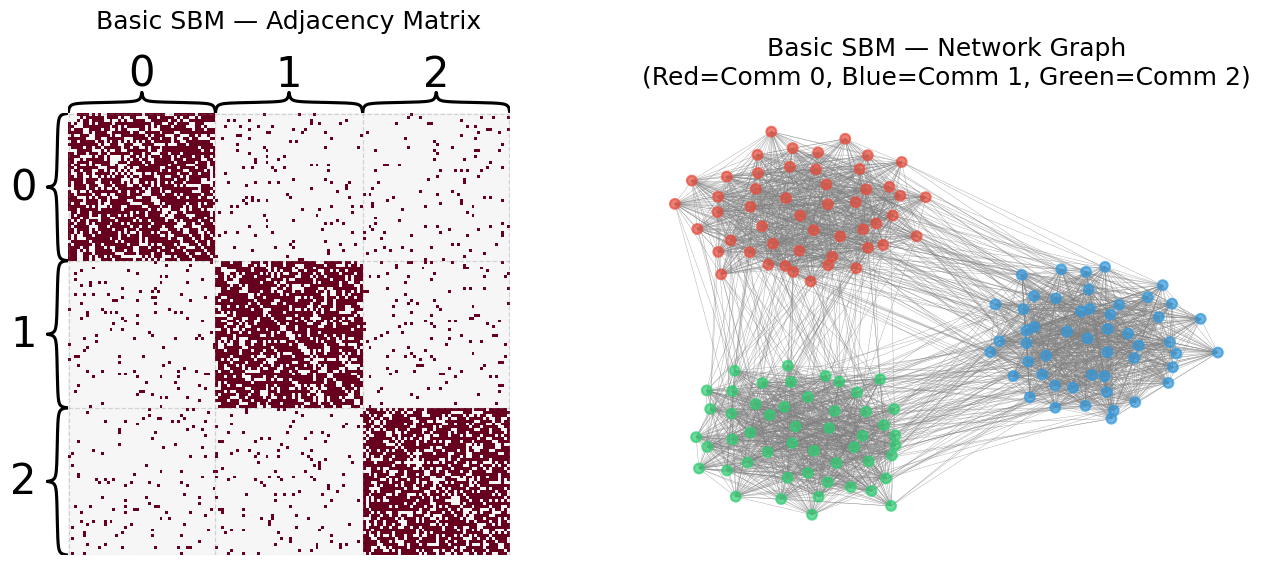

In [2]:
# Now we would like to visualize the graph representation using heatmap
# and visualizing the graph 
# Visualize as heatmap — should see 3 clear dark blocks on the diagonal
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap
heatmap(
    A,
    inner_hier_labels=labels,
    title='Basic SBM — Adjacency Matrix',
    ax=axs[0],
    cbar=False
)

# Network graph
G = nx.from_numpy_array(A)
color_map = ['#e74c3c', '#3498db', '#2ecc71']  # red, blue, green
node_colors = [color_map[labels[node]] for node in G.nodes()]
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G, pos=pos,
    node_color=node_colors,
    node_size=50,
    with_labels=False,
    edge_color='gray',
    alpha=0.7,
    width=0.3,
    ax=axs[1]
)
axs[1].set_title('Basic SBM — Network Graph\n(Red=Comm 0, Blue=Comm 1, Green=Comm 2)')
axs[1].axis('off')

plt.tight_layout()
plt.show()

### DSBM simulation

In [3]:
# Now we want to generate a DSBM sample graph, same specific as the 
# above generated SBM data - just different model
from graspologic.simulations import sbm

# --- Generate DCSBM: 3 communities, 50 nodes each ---

n_nodes = 150
n_per_block = 50

# Sample theta for each node from uniform distribution [0, 1]
theta = np.random.uniform(0, 1, size=n_nodes)

# Block probability matrix (same structure as basic SBM)
B_dc = np.array([
    [0.7, 0.05, 0.05],
    [0.05, 0.7, 0.05],
    [0.05, 0.05, 0.7],
])

# Build the full probability matrix P manually
# P_ij = theta_i * theta_j * B[community_i][community_j]
labels_dc = np.repeat([0, 1, 2], n_per_block)

P_dc = np.zeros((n_nodes, n_nodes))
for i in range(n_nodes):
    for j in range(n_nodes):
        if i != j:
            P_dc[i, j] = theta[i] * theta[j] * B_dc[labels_dc[i], labels_dc[j]]

# Sample adjacency matrix from P
A_dc = (np.random.rand(n_nodes, n_nodes) < P_dc).astype(int)
A_dc = np.triu(A_dc, 1)   # keep upper triangle only (undirected)
A_dc = A_dc + A_dc.T      # symmetrize

print(f'Adjacency matrix shape: {A_dc.shape}')
print(f'Theta min: {theta.min():.3f}, max: {theta.max():.3f}, mean: {theta.mean():.3f}')

Adjacency matrix shape: (150, 150)
Theta min: 0.008, max: 0.999, mean: 0.473


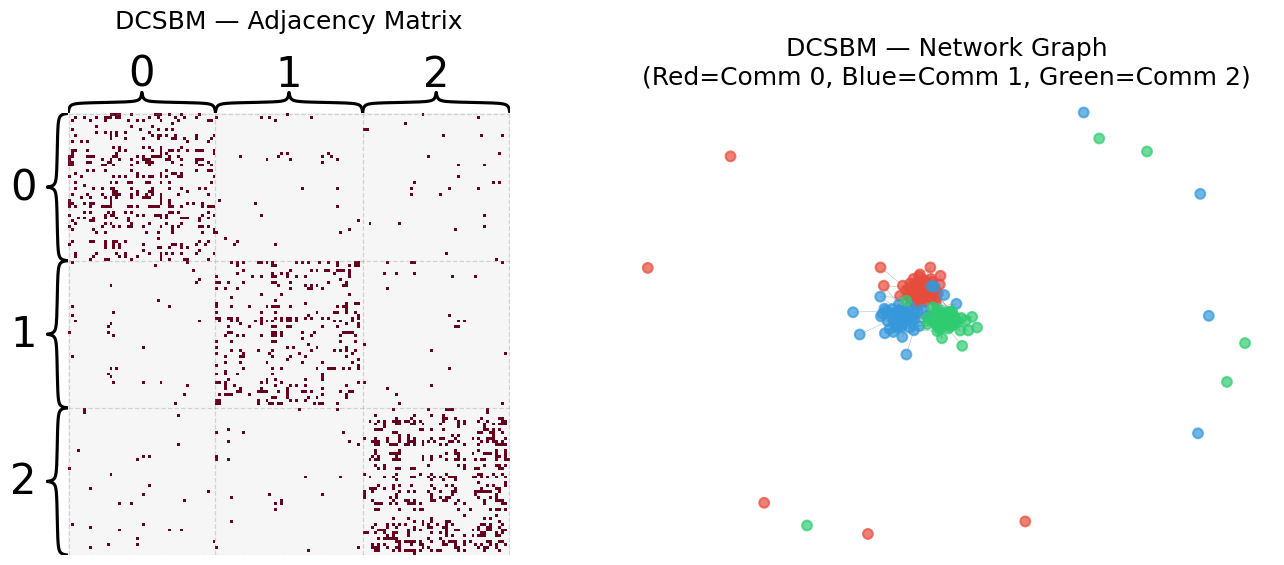

In [4]:
# Visualize DCSBM as heatmap + network graph
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap
heatmap(
    A_dc,
    inner_hier_labels=labels_dc,
    title='DCSBM — Adjacency Matrix',
    ax=axs[0],
    cbar=False
)

# Network graph
G_dc = nx.from_numpy_array(A_dc)
color_map = ['#e74c3c', '#3498db', '#2ecc71']
node_colors_dc = [color_map[labels_dc[node]] for node in G_dc.nodes()]
pos_dc = nx.spring_layout(G_dc, seed=42)

nx.draw_networkx(
    G_dc, pos=pos_dc,
    node_color=node_colors_dc,
    node_size=50,
    with_labels=False,
    edge_color='gray',
    alpha=0.7,
    width=0.3,
    ax=axs[1]
)
axs[1].set_title('DCSBM — Network Graph\n(Red=Comm 0, Blue=Comm 1, Green=Comm 2)')
axs[1].axis('off')

plt.tight_layout()
plt.show()

### RDPG Simulation

In [5]:
# Now here would be the RDPG - random dot product graph, we would simulate this \
# model and generate the sample graph using this model

# --- Generate RDPG with 3 communities, 50 nodes each ---

n_nodes = 150
n_per_block = 50
d = 2  # dimension of latent vectors

# Base vectors for each community (their "home" in 2D space)
base_vectors = np.array([
    [0.9, 0.1],   # community 0 lives top-left
    [0.1, 0.9],   # community 1 lives top-right  
    [0.4, 0.6],   # community 2 lives in the middle
])

std = 0.05  # small noise around the base vector

# Sample latent position for each node ~ Normal(base_vector, std)
X = np.zeros((n_nodes, d))
labels_rdpg = np.repeat([0, 1, 2], n_per_block)

for comm in range(3):
    mask = labels_rdpg == comm
    X[mask] = np.random.normal(
        loc=base_vectors[comm],   # mean = community base vector
        scale=std,                # variance = std
        size=(n_per_block, d)
    )

# Compute probability matrix P = X @ X.T
P_rdpg = X @ X.T

# Clip to [0, 1] to ensure valid probabilities
P_rdpg = np.clip(P_rdpg, 0, 1)

# Sample adjacency matrix from P
A_rdpg = (np.random.rand(n_nodes, n_nodes) < P_rdpg).astype(int)
A_rdpg = np.triu(A_rdpg, 1)   # upper triangle only (undirected)
A_rdpg = A_rdpg + A_rdpg.T    # symmetrize

print(f'X shape: {X.shape}')
print(f'P_rdpg shape: {P_rdpg.shape}')
print(f'Base vectors:\n{base_vectors}')
print(f'Sample latent positions (first 3 nodes of each community):')
for comm in range(3):
    mask = labels_rdpg == comm
    print(f'  Community {comm}: {X[mask][:3].round(3)}')

X shape: (150, 2)
P_rdpg shape: (150, 150)
Base vectors:
[[0.9 0.1]
 [0.1 0.9]
 [0.4 0.6]]
Sample latent positions (first 3 nodes of each community):
  Community 0: [[0.88  0.089]
 [0.901 0.076]
 [0.912 0.096]]
  Community 1: [[0.046 0.808]
 [0.137 0.933]
 [0.112 0.875]]
  Community 2: [[0.375 0.73 ]
 [0.426 0.7  ]
 [0.475 0.568]]


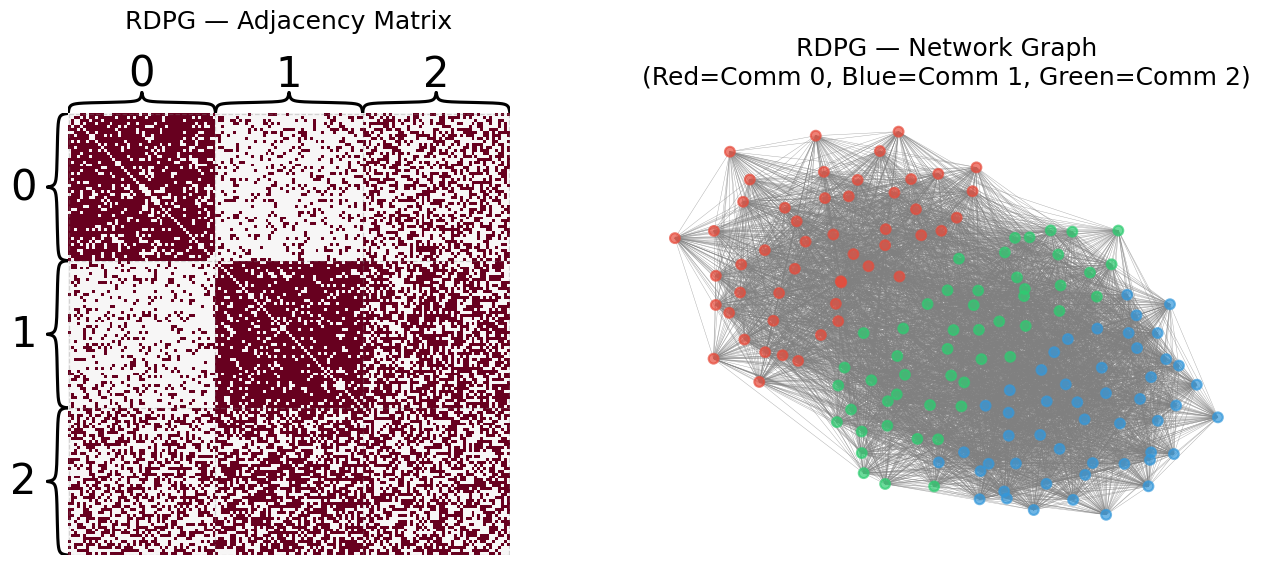

In [6]:
# Visualize RDPG as heatmap + network graph
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap
heatmap(
    A_rdpg,
    inner_hier_labels=labels_rdpg,
    title='RDPG — Adjacency Matrix',
    ax=axs[0],
    cbar=False
)

# Network graph
G_rdpg = nx.from_numpy_array(A_rdpg)
color_map = ['#e74c3c', '#3498db', '#2ecc71']
node_colors_rdpg = [color_map[labels_rdpg[node]] for node in G_rdpg.nodes()]
pos_rdpg = nx.spring_layout(G_rdpg, seed=42)

nx.draw_networkx(
    G_rdpg, pos=pos_rdpg,
    node_color=node_colors_rdpg,
    node_size=50,
    with_labels=False,
    edge_color='gray',
    alpha=0.7,
    width=0.3,
    ax=axs[1]
)
axs[1].set_title('RDPG — Network Graph\n(Red=Comm 0, Blue=Comm 1, Green=Comm 2)')
axs[1].axis('off')

plt.tight_layout()
plt.show()

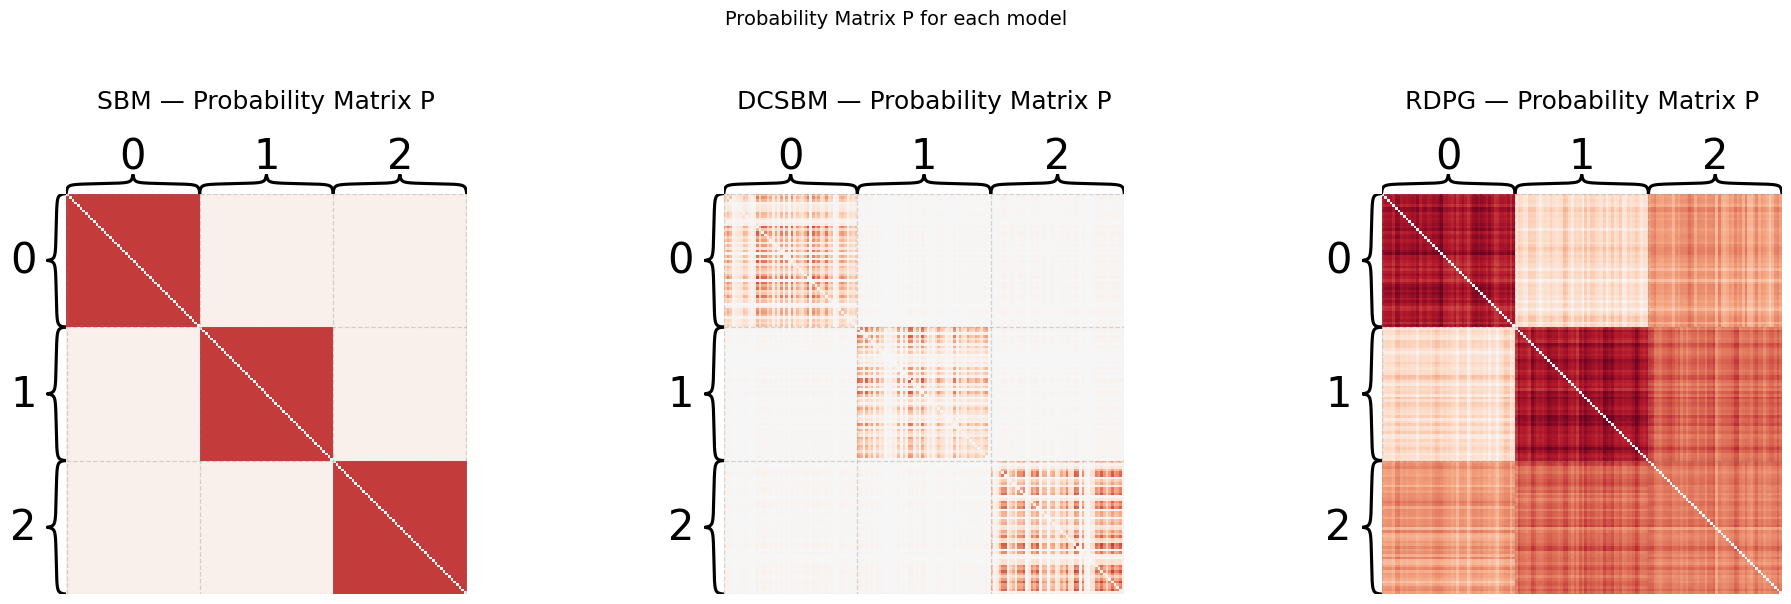

In [7]:
# Visualize probability matrix P for all 3 models side by side
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# Basic SBM probability matrix
# P_ij = B[comm_i][comm_j]
P_sbm = np.zeros((150, 150))
for i in range(150):
    for j in range(150):
        P_sbm[i, j] = B[labels[i], labels[j]]
np.fill_diagonal(P_sbm, 0)  # no self loops

heatmap(P_sbm, inner_hier_labels=labels, title='SBM — Probability Matrix P',
        ax=axs[0], cbar=False, vmin=0, vmax=1)

# DCSBM probability matrix (already computed as P_dc)
np.fill_diagonal(P_dc, 0)
heatmap(P_dc, inner_hier_labels=labels_dc, title='DCSBM — Probability Matrix P',
        ax=axs[1], cbar=False, vmin=0, vmax=1)

# RDPG probability matrix (already computed as P_rdpg)
np.fill_diagonal(P_rdpg, 0)
heatmap(P_rdpg, inner_hier_labels=labels_rdpg, title='RDPG — Probability Matrix P',
        ax=axs[2], cbar=False, vmin=0, vmax=1)

plt.suptitle('Probability Matrix P for each model', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Secondly, playaround with some embedding algorithms

### ASE Embedding Algorithms

c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\graspologic\embed\base.py:199: UserWarning: Input graph is not fully connected. Results may notbe optimal. You can compute the largest connected component byusing ``graspologic.utils.largest_connected_component``.
  warnings.warn(msg, UserWarning)


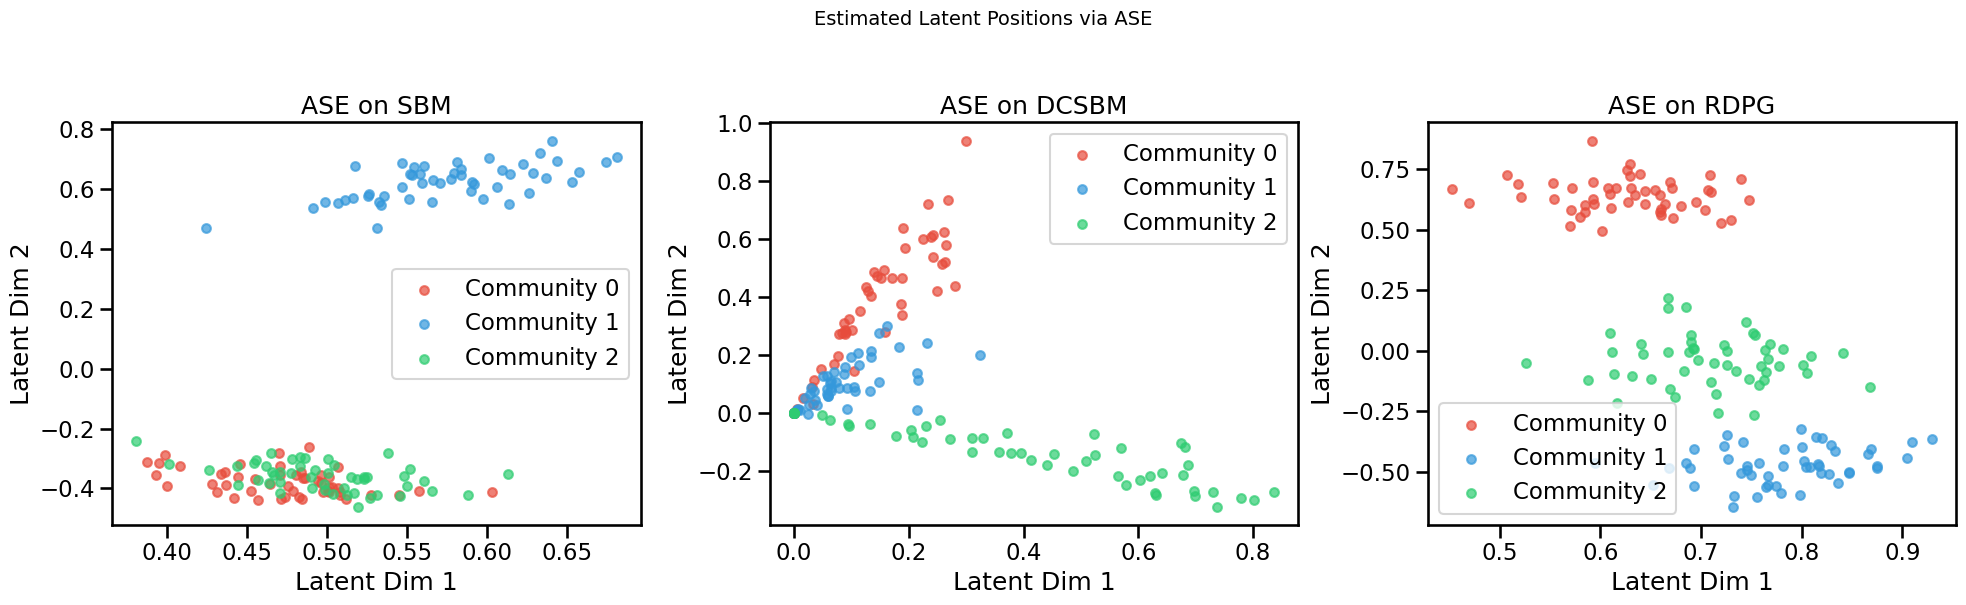

In [8]:
from graspologic.embed import AdjacencySpectralEmbed

# Apply ASE to all 3 networks
ase = AdjacencySpectralEmbed(n_components=2)

X_hat_sbm  = ase.fit_transform(A)        # basic SBM
X_hat_dc   = ase.fit_transform(A_dc)     # DCSBM
X_hat_rdpg = ase.fit_transform(A_rdpg)   # RDPG

# Plot estimated latent positions for all 3
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

color_map = ['#e74c3c', '#3498db', '#2ecc71']
datasets = [
    (X_hat_sbm,  labels,       'ASE on SBM'),
    (X_hat_dc,   labels_dc,    'ASE on DCSBM'),
    (X_hat_rdpg, labels_rdpg,  'ASE on RDPG'),
]

for i, (X_hat, labs, title) in enumerate(datasets):
    for comm in range(3):
        mask = labs == comm
        axs[i].scatter(
            X_hat[mask, 0], X_hat[mask, 1],
            c=color_map[comm], label=f'Community {comm}',
            alpha=0.7, s=40
        )
    axs[i].set_title(title)
    axs[i].set_xlabel('Latent Dim 1')
    axs[i].set_ylabel('Latent Dim 2')
    axs[i].legend()

plt.suptitle('Estimated Latent Positions via ASE', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### DeepWalk / Node2Vec Embedding Algorithms

c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\graspologic\embed\n2v.py:148: UserWarning: Isolated nodes found: [10, 18, 22, 32, 41, 52, 60, 73, 99, 113, 118, 121, 133, 135]
  warnings.warn(f"Isolated nodes found: {isolated_nodes}")
c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


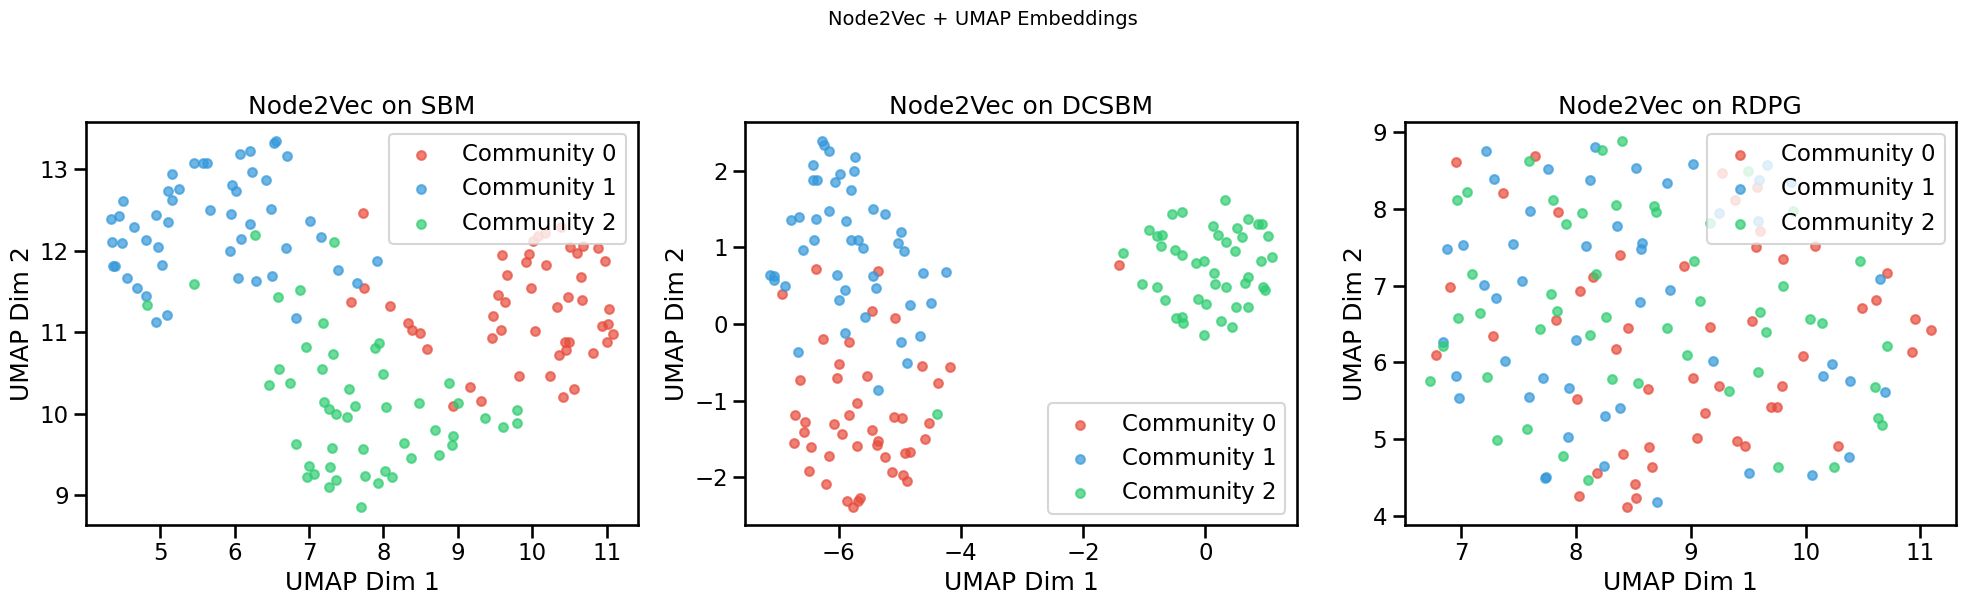

In [9]:
from graspologic.embed import node2vec_embed
from umap import UMAP

# Apply Node2Vec to all 3 networks
# Convert adjacency matrices to networkx graphs first
G_sbm   = nx.from_numpy_array(A)
G_dc    = nx.from_numpy_array(A_dc)
G_rdpg  = nx.from_numpy_array(A_rdpg)

# Run Node2Vec on all 3
params = dict(
    dimensions=16,
    num_walks=10,
    walk_length=20,
    inout_hyperparameter=1.0,   # q: balance local vs global
    return_hyperparameter=1.0,  # p: return probability
    random_seed=42
)

emb_sbm,  ids_sbm  = node2vec_embed(G_sbm,  **params)
emb_dc,   ids_dc   = node2vec_embed(G_dc,   **params)
emb_rdpg, ids_rdpg = node2vec_embed(G_rdpg, **params)

# UMAP to reduce from 16D to 2D for visualization
umap = UMAP(n_components=2, metric='cosine', random_state=42)

emb_sbm_2d  = umap.fit_transform(emb_sbm)
emb_dc_2d   = umap.fit_transform(emb_dc)
emb_rdpg_2d = umap.fit_transform(emb_rdpg)

# Plot
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

color_map = ['#e74c3c', '#3498db', '#2ecc71']
datasets = [
    (emb_sbm_2d,  ids_sbm,  labels,       'Node2Vec on SBM'),
    (emb_dc_2d,   ids_dc,   labels_dc,    'Node2Vec on DCSBM'),
    (emb_rdpg_2d, ids_rdpg, labels_rdpg,  'Node2Vec on RDPG'),
]

for i, (emb_2d, ids, labs, title) in enumerate(datasets):
    # Reorder labels to match node_ids from node2vec
    reordered_labels = np.array([labs[nid] for nid in ids])
    for comm in range(3):
        mask = reordered_labels == comm
        axs[i].scatter(
            emb_2d[mask, 0], emb_2d[mask, 1],
            c=color_map[comm], label=f'Community {comm}',
            alpha=0.7, s=40
        )
    axs[i].set_title(title)
    axs[i].set_xlabel('UMAP Dim 1')
    axs[i].set_ylabel('UMAP Dim 2')
    axs[i].legend()

plt.suptitle('Node2Vec + UMAP Embeddings', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Thirdly, playing with a real - world dataset: CORA - citations network

In [7]:
# Download Cora dataset directly without torch
import urllib.request
import zipfile
import os

# Download from kimiyoung's github (standard Cora source)
url = "https://linqs-data.soe.ucsc.edu/public/lbc/cora.tgz"
urllib.request.urlretrieve(url, "cora.tgz")

# Extract
import tarfile
with tarfile.open("cora.tgz", "r:gz") as tar:
    tar.extractall(".")

print("Downloaded and extracted!")
print(os.listdir("cora"))

import networkx as nx
import pandas as pd
import numpy as np

# Load edges
edges = pd.read_csv("cora/cora.cites", sep="\t", header=None, names=["target", "source"])

# Load node labels
content = pd.read_csv("cora/cora.content", sep="\t", header=None)
content.columns = ["node_id"] + [f"feat_{i}" for i in range(content.shape[1]-2)] + ["label"]

# Build graph
G_cora = nx.from_pandas_edgelist(edges, source="source", target="target", create_using=nx.Graph())

# Map string labels to integers
label_map = {label: i for i, label in enumerate(content["label"].unique())}
content["label_int"] = content["label"].map(label_map)

# Build label array aligned to node order
node_to_label = dict(zip(content["node_id"], content["label_int"]))
node_to_labelname = dict(zip(content["node_id"], content["label"]))

print(f'Nodes (papers): {G_cora.number_of_nodes()}')
print(f'Edges (citations): {G_cora.number_of_edges()}')
print(f'Categories: {content["label"].unique()}')

Downloaded and extracted!
['cora.cites', 'cora.content', 'README']
Nodes (papers): 2708
Edges (citations): 5278
Categories: ['Neural_Networks' 'Rule_Learning' 'Reinforcement_Learning'
 'Probabilistic_Methods' 'Theory' 'Genetic_Algorithms' 'Case_Based']


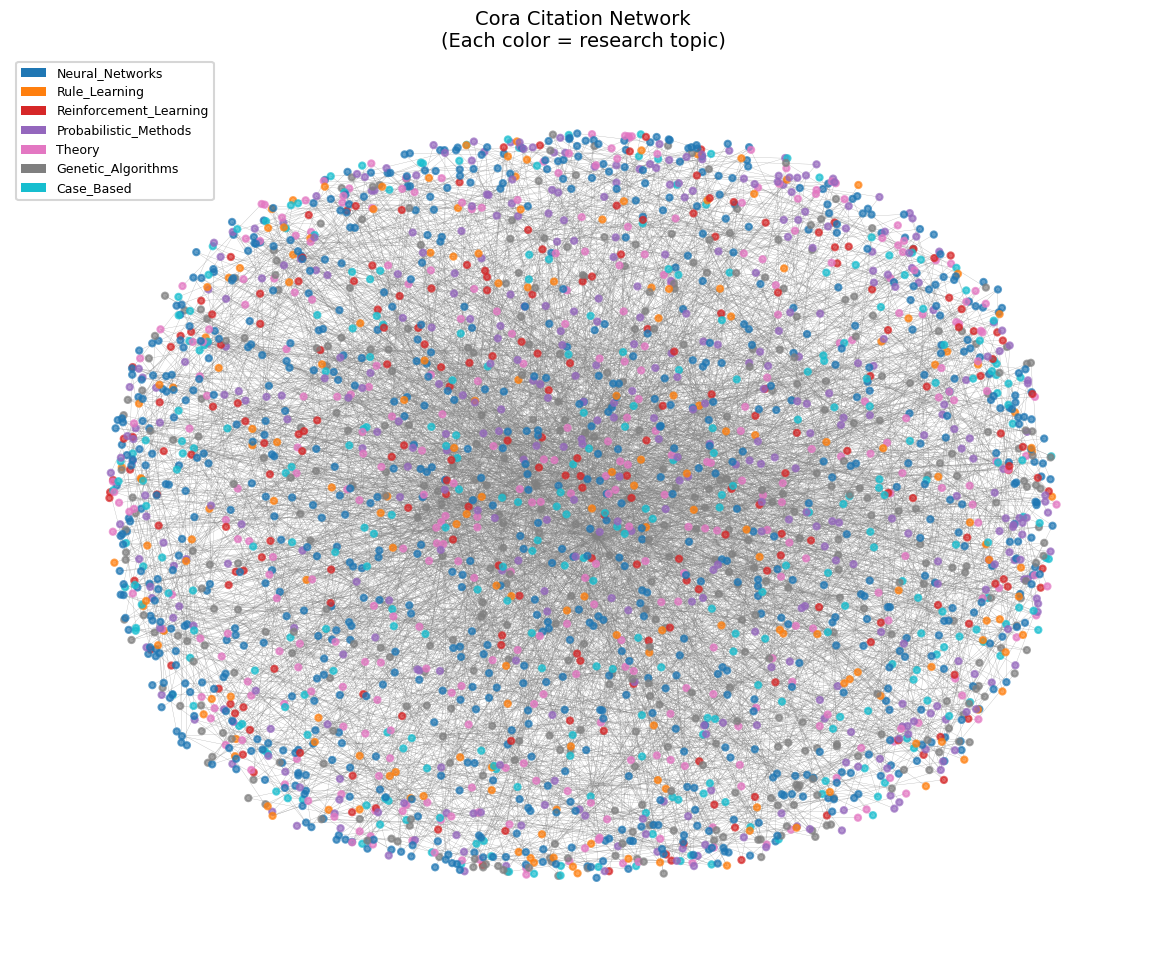

Total papers: 2708
Total citations: 5278


In [8]:
# Visualizing the network
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context('talk')

# Get labels aligned to graph node order
node_list = list(G_cora.nodes())
node_colors_cora = [node_to_label.get(node, 0) for node in node_list]

# Get unique categories and assign colors
n_categories = len(label_map)
colors_7 = plt.cm.tab10(np.linspace(0, 0.9, n_categories))
node_color_rgb = [colors_7[node_to_label.get(node, 0)] for node in node_list]

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

pos_cora = nx.spring_layout(G_cora, seed=42, k=0.3)

nx.draw_networkx(
    G_cora, pos=pos_cora,
    node_color=node_color_rgb,
    node_size=20,
    with_labels=False,
    edge_color='gray',
    alpha=0.7,
    width=0.2,
    ax=ax
)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors_7[i], label=label)
    for label, i in label_map.items()
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
ax.set_title('Cora Citation Network\n(Each color = research topic)', fontsize=14)
ax.axis('off')

plt.tight_layout()
plt.show()

print(f'Total papers: {G_cora.number_of_nodes()}')
print(f'Total citations: {G_cora.number_of_edges()}')

In [9]:
from graspologic.embed import AdjacencySpectralEmbed
from graspologic.embed import node2vec_embed
from graspologic.utils import pass_to_ranks
from umap import UMAP
from scipy.sparse import csr_matrix

# Convert to adjacency matrix (sparse — more efficient for large graphs)
A_cora = nx.to_scipy_sparse_array(G_cora, nodelist=node_list)

# --- ASE ---
ase_cora = AdjacencySpectralEmbed(n_components=16)
X_ase_cora = ase_cora.fit_transform(pass_to_ranks(A_cora))

# --- Node2Vec ---
emb_cora, ids_cora = node2vec_embed(
    G_cora,
    dimensions=16,
    num_walks=10,
    walk_length=20,
    inout_hyperparameter=1.0,
    return_hyperparameter=1.0,
    random_seed=42
)

print('Embeddings done!')
print(f'ASE shape: {X_ase_cora.shape}')
print(f'Node2Vec shape: {emb_cora.shape}')

c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\graspologic\embed\base.py:199: UserWarning: Input graph is not fully connected. Results may notbe optimal. You can compute the largest connected component byusing ``graspologic.utils.largest_connected_component``.
  warnings.warn(msg, UserWarning)
c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\graspologic\utils\utils.py:1142: UserWarning: Graph has at least one unweighted edge using weight_attribute "weight". Defaulting unweighted edges to "1.0"
  warnings.warn(


Embeddings done!
ASE shape: (2708, 16)
Node2Vec shape: (2708, 16)


c:\Users\ADMIN\AppData\Local\Programs\Python\Python39\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


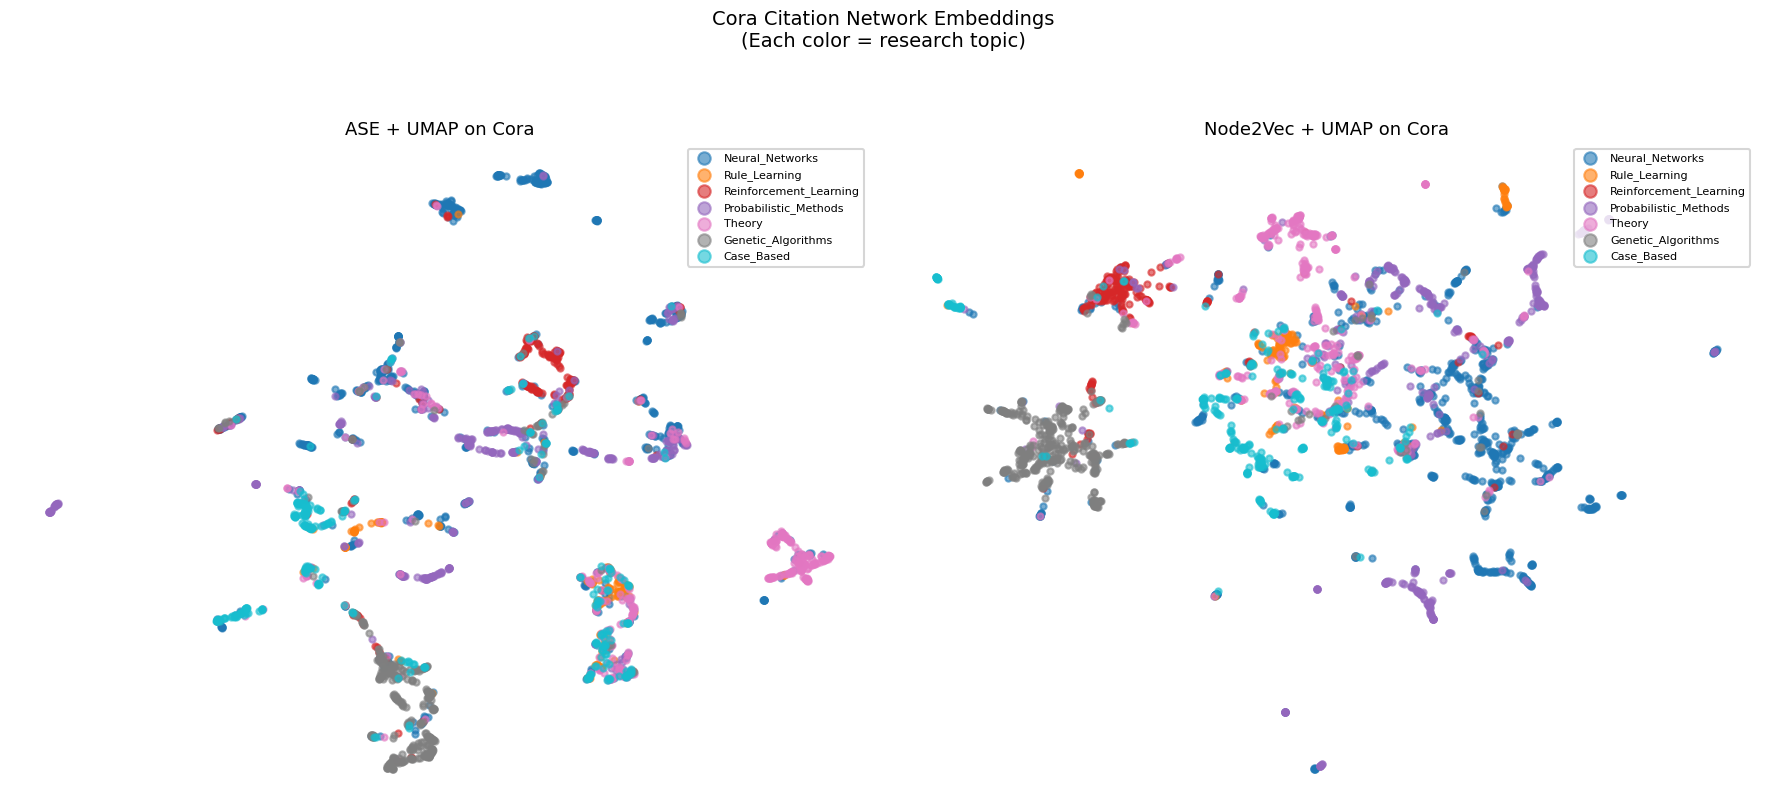

In [10]:
# UMAP reduce both to 2D
umap = UMAP(n_components=2, metric='cosine', random_state=42)

X_ase_2d  = umap.fit_transform(X_ase_cora)
X_n2v_2d  = umap.fit_transform(emb_cora)

# Align labels to correct node ordering
cora_labels_ase = np.array([node_to_label.get(node, 0) for node in node_list])
cora_labels_n2v = np.array([node_to_label.get(node, 0) for node in ids_cora])

# Plot side by side
fig, axs = plt.subplots(1, 2, figsize=(18, 8))

datasets = [
    (X_ase_2d,  cora_labels_ase, 'ASE + UMAP on Cora'),
    (X_n2v_2d,  cora_labels_n2v, 'Node2Vec + UMAP on Cora'),
]

for i, (X, labs, title) in enumerate(datasets):
    for cat, (label_name, label_idx) in enumerate(label_map.items()):
        mask = labs == label_idx
        axs[i].scatter(
            X[mask, 0], X[mask, 1],
            c=[colors_7[label_idx]],
            label=label_name,
            alpha=0.6, s=20
        )
    axs[i].set_title(title, fontsize=13)
    axs[i].legend(loc='upper right', fontsize=8, markerscale=2)
    axs[i].axis('off')

plt.suptitle('Cora Citation Network Embeddings\n(Each color = research topic)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()